In [74]:
import os
import json
import pandas as pd
import numpy as np
import glob
import copy

# Define the root directory
root_dir = 'results_2511'

# List to store the extracted data
all_records = []

pred_meaning_map = {
    "A": "Yes",
    "B": "No",
    "C1": "Empty Collection",
    "C2": "No Valid Pixels",
    "C3": "Calculation Failure",
    "D": "Execution Error"
}

# Walk through the directory structure
# We assume structure: results_2511/strategy/language/model_folder/json_file

count = 0
for root, dirs, files in os.walk(root_dir):

    if "zero_shot+specific" in root.lower(): continue  # Skip specific model runs if needed
    if "javascript" in root.lower(): continue  # Skip javascript files if needed
    
    if "gpt-5" not in root.lower() and "gemini-2.5-pro" not in root.lower() and "claude-sonnet" not in root.lower():
        continue  # Filter for specific models if needed

    print("Processing directory:", root)

    for file in files:
        if file.endswith('.json'):
            file_path = os.path.join(root, file)

            if "zero_shot" in file_path and os.path.exists(file_path.replace("zero_shot", "reflexion_1")):
                continue

            if "reflexion_1" in file_path and os.path.exists(file_path.replace("reflexion_1", "reflexion_2")):
                continue

            # Read JSON content
            with open(file_path, 'r') as f:
                content = json.load(f)
            
            # Extract sections
            metadata = content.get('metadata', {})
                
            # --- 1. Extract Info from Folder Structure (as requested) ---
            # Get path parts to identify language and model string
            path_parts = os.path.normpath(file_path).split(os.sep)
            
            # Assuming depth: .../language/model_folder/file.json
            # Python negative indexing is safer:
            language_from_folder = path_parts[-3] if len(path_parts) >= 3 else "unknown"
            model_folder_name = path_parts[-2] if len(path_parts) >= 2 else "unknown"
            
            # Parse "code_llm" and "answer_llm" from folder name
            # Format: "generator+verifier__v1"
            if '+' in model_folder_name:
                parts = model_folder_name.split('__')[0].split('+')
                folder_code_llm = parts[0]
                folder_answer_llm = parts[1] if len(parts) > 1 else "unknown"
            else:
                folder_code_llm = model_folder_name
                folder_answer_llm = "unknown"

            # --- 2. Process Ground Truth (GT) ---
            # Logic: NaN -> Yes, "No" -> No
            raw_gt = metadata.get('answer')
            
            gt_normalized = "Unknown"
            
            # Handle Float NaN, None, or String "NaN"
            is_nan = False
            if raw_gt is None:
                is_nan = True
            elif isinstance(raw_gt, float) and np.isnan(raw_gt):
                is_nan = True
            elif str(raw_gt).strip() == "NaN":
                is_nan = True
                
            if is_nan:
                gt_normalized = "Yes"
            elif str(raw_gt).lower().strip() == "no":
                gt_normalized = "No"
            else:
                # Keep original if it's something unexpected (e.g. "Yes")
                gt_normalized = str(raw_gt)

            # --- 3. Process Model Prediction ---
            # Taking the first iteration from 'data' list
            data_list = content.get('data', [])
            if not data_list: continue
            model_data = data_list[0]
            prediction_code = model_data.get('answer')
            # Map codes to meanings for readability (optional, but helpful)

            zs_pred_meaning = pred_meaning_map.get(prediction_code, "Unknown Code")

            # --- 4. Build Record ---
            record = {
                "unique_id": metadata.get('unique_id'),
                "filename": file,
                "language": metadata.get('language') or language_from_folder,
                "strategy": metadata.get('strategy'),
                "code_llm": metadata.get('code_llm', folder_code_llm),
                "answer_llm": metadata.get('answer_llm', folder_answer_llm),
                "folder_name": model_folder_name, # Kept for verification
                "gt_raw": raw_gt,
                "gt_answer": gt_normalized,
                "pred_code": prediction_code,
                "pred_meaning": zs_pred_meaning,
                "exec_returncode": model_data.get('exec_returncode'),
                "question": metadata.get('question'), 
                "stage": "zero_shot"
            }            
            all_records.append(record)

            # proceed to reflexion_1

            # get the rfx_1 answer
            rfx_data_1 = content.get('reflexion_1', [])
            if not rfx_data_1:
                rfx_1_code = copy.deepcopy(prediction_code)
                rfx_1_meaning = copy.deepcopy(zs_pred_meaning)
            else:
                rfx_1_code = rfx_data_1[0]["answer"]
                rfx_1_meaning = pred_meaning_map.get(rfx_1_code, "Unknown Code")
            rfx_record = copy.deepcopy(record)
            rfx_record.update({
                "pred_code": rfx_1_code,
                "pred_meaning": rfx_1_meaning,
                "stage": "reflexion1",
            })
            all_records.append(rfx_record)



            rfx_data_2 = content.get('reflexion_2', [])
            if not rfx_data_2:
                rfx_2_code = copy.deepcopy(rfx_1_code)
                rfx_2_meaning = copy.deepcopy(rfx_1_meaning)
            else:
                rfx_2_code = rfx_data_2[0]["answer"]
                rfx_2_meaning = pred_meaning_map.get(rfx_2_code, "Unknown Code")
                count += 1
            rfx2_record = copy.deepcopy(record)
            rfx2_record.update({
                "pred_code": rfx_2_code,
                "pred_meaning": rfx_2_meaning,
                "stage": "reflexion2",
            })
            all_records.append(rfx2_record)
            

# Create DataFrame
df = pd.DataFrame(all_records)

# Sort for cleaner viewing (e.g., by LLM and ID)
if not df.empty:
    df = df.sort_values(by=['code_llm', 'unique_id'])

# Display info
print(f"Total files processed: {len(df)}")
print("Columns available:", df.columns.tolist())

# Show the first few rows
df.head()
print(count)

Processing directory: results_2511/reflexion_1/python/gemini-2.5-pro+gemini-2.5-flash__v1
Processing directory: results_2511/reflexion_1/python/gpt-5+gemini-2.5-flash__v1
Processing directory: results_2511/reflexion_1/python/claude-sonnet-4-5-20250929+gemini-2.5-flash__v1
Processing directory: results_2511/zero_shot/python/gemini-2.5-pro+gemini-2.5-flash__v1
Processing directory: results_2511/zero_shot/python/gpt-5+gemini-2.5-flash__v1
Processing directory: results_2511/zero_shot/python/claude-sonnet-4-5-20250929+gemini-2.5-flash__v1
Processing directory: results_2511/reflexion_2/python/gemini-2.5-pro+gemini-2.5-flash__v1
Processing directory: results_2511/reflexion_2/python/gpt-5+gemini-2.5-flash__v1
Processing directory: results_2511/reflexion_2/python/claude-sonnet-4-5-20250929+gemini-2.5-flash__v1
Total files processed: 3624
Columns available: ['unique_id', 'filename', 'language', 'strategy', 'code_llm', 'answer_llm', 'folder_name', 'gt_raw', 'gt_answer', 'pred_code', 'pred_meaning

In [75]:
# df drop duplicates based on unique_id, language, strategy, code_llm, answer_llm, stage keeping the last occurrence
df = df.drop_duplicates(subset=['unique_id', 'language', 'strategy', 'code_llm', 'answer_llm', 'stage'], keep='last')
print(f"Total records after dropping duplicates: {len(df)}")

Total records after dropping duplicates: 3624


In [76]:
df_claude = df[df['code_llm'].str.contains("gpt-5", case=False, na=False)]
print(f"Total records for Claude models: {len(df_claude)}")

Total records for Claude models: 1200


In [77]:
df_claude["stage"].value_counts()

stage
zero_shot     400
reflexion1    400
reflexion2    400
Name: count, dtype: int64

/var/folders/mk/sm66qh5d415_q45h2zny_dr80000gp/T/ipykernel_67523/1939037612.py:53: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stack_data = df_target.groupby(['code_llm', 'stage', 'outcome']).size().unstack(fill_value=0)


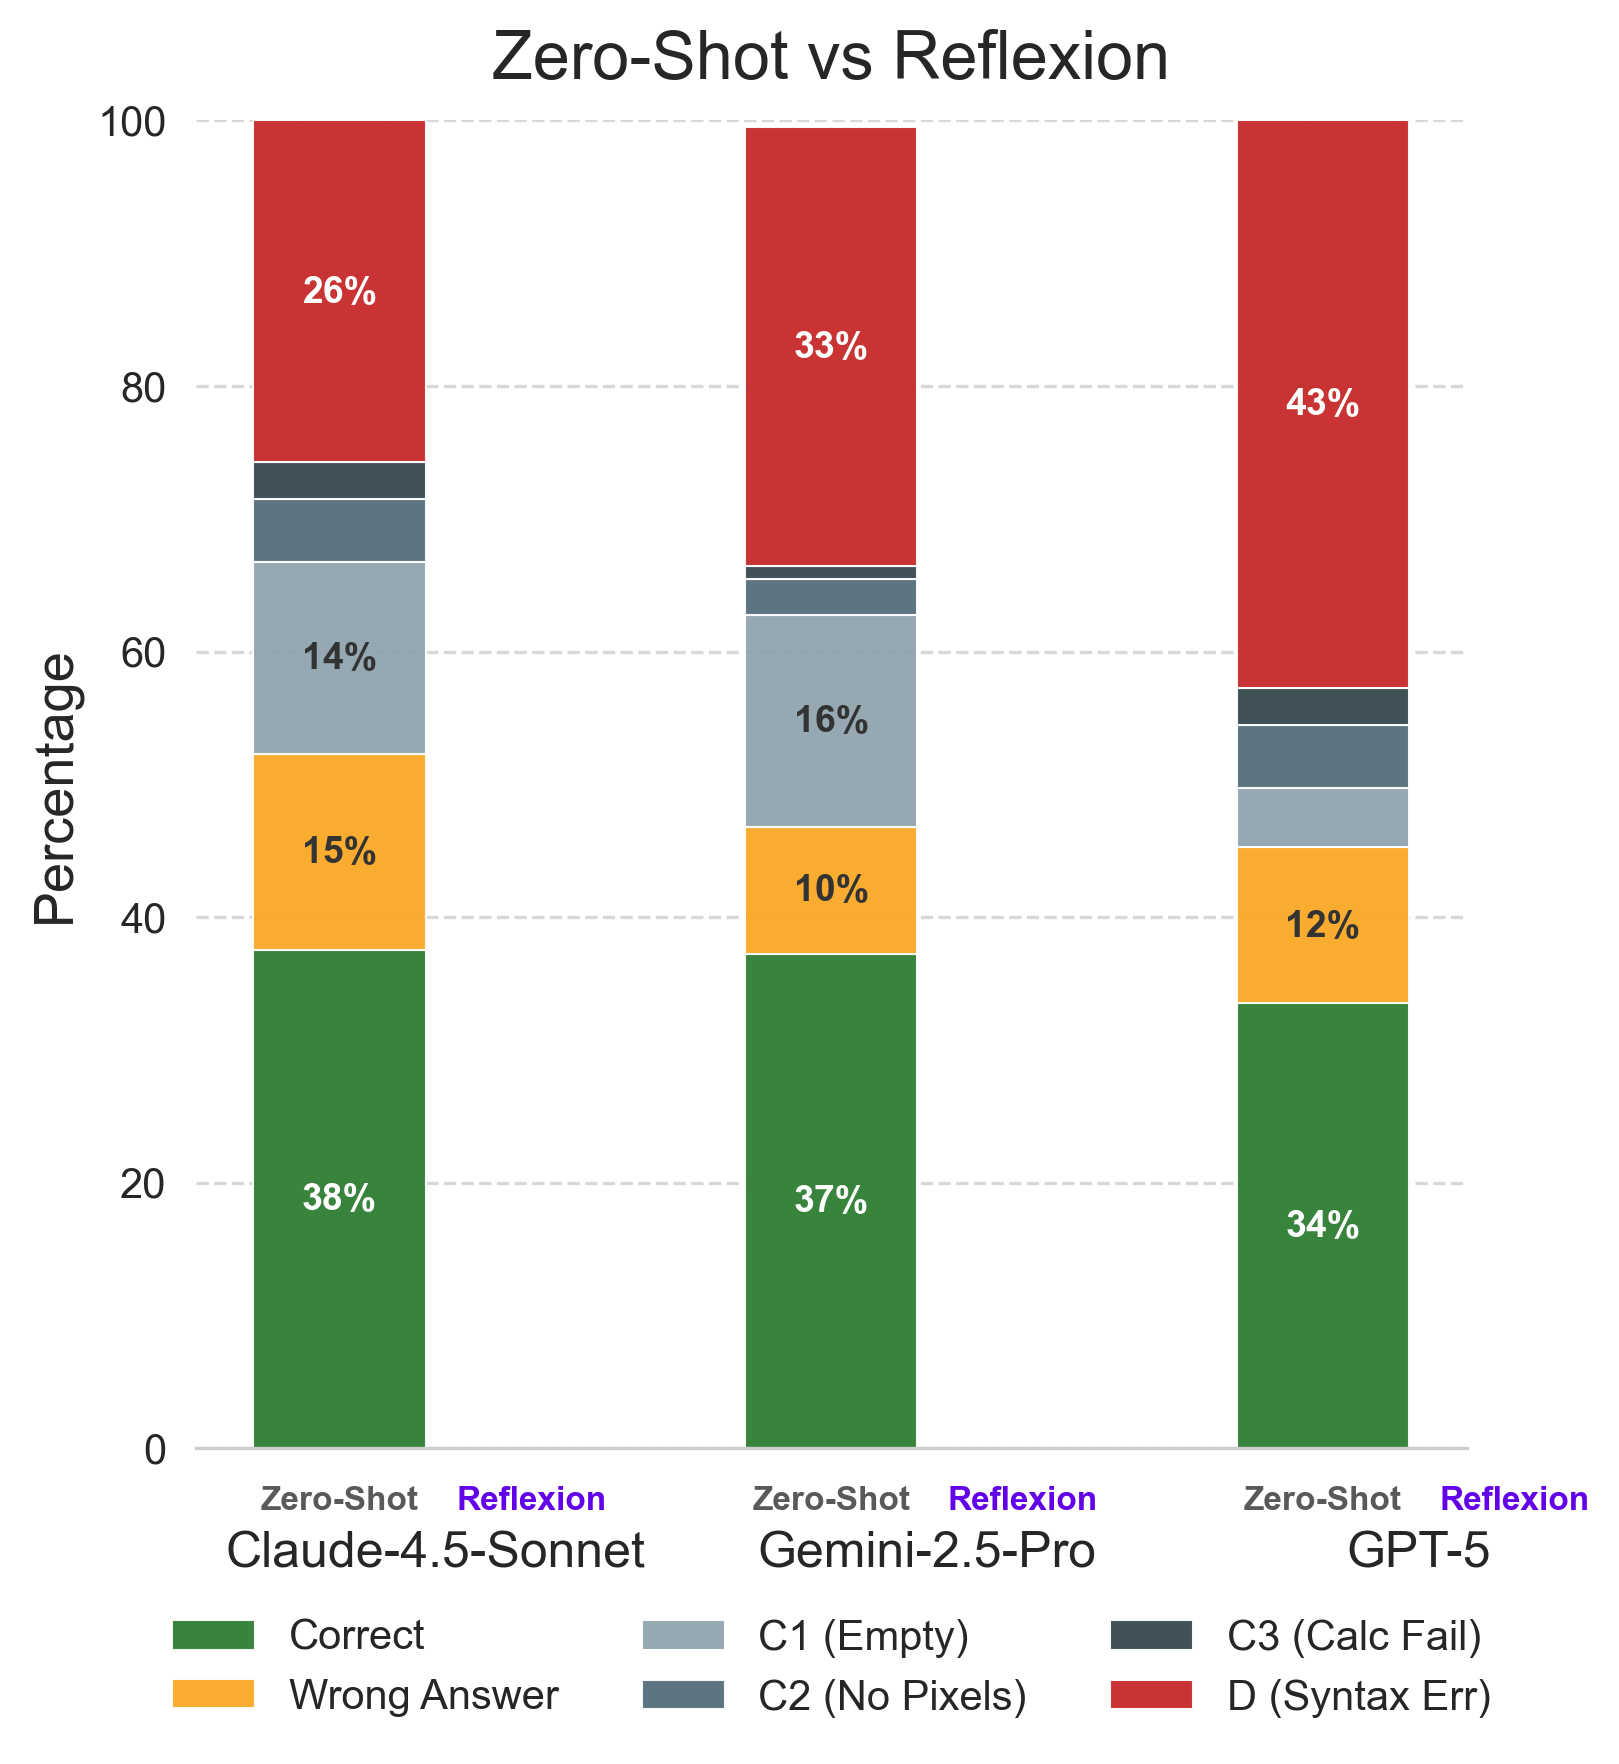

In [78]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 1. CONFIGURATION & DATA PREP ---

# NOTE: Assumes 'df' is loaded with columns: 'code_llm', 'gt_answer', 'pred_code', 'stage'
# 'stage' values should be: 'zero_shot', 'reflexion'

# Define Models and Order
target_models = ['claude-sonnet-4-5-20250929', 'gemini-2.5-pro', 'gpt-5']
model_labels = ['Claude-4.5-Sonnet', 'Gemini-2.5-Pro', 'GPT-5']

# Filter Data
df_target = df[df['code_llm'].isin(target_models)].copy()
df_target['code_llm'] = pd.Categorical(df_target['code_llm'], categories=target_models, ordered=True)

# Define Outcomes
def categorize_result(row):
    gt = row['gt_answer']
    pred = row['pred_code']
    if (gt == 'Yes' and pred == 'A') or (gt == 'No' and pred == 'B'): return 'Correct'
    elif pred in ['A', 'B']: return 'Wrong Answer'
    elif pred == 'C1': return 'C1 (Empty)'
    elif pred == 'C2': return 'C2 (No Pixels)'
    elif pred == 'C3': return 'C3 (Calc Fail)'
    elif pred == 'D':  return 'D (Syntax Err)'
    return 'Unknown'

df_target['outcome'] = df_target.apply(categorize_result, axis=1)

# --- 2. COLOR PALETTES ---

# Text Colors for Stage labels
# Grey for Zero-Shot (Baseline), Blue/Purple for Reflexion (Improved)
stage_colors = {'zero_shot': '#595959', 'reflexion': '#6200EA'} 

# Outcome Colors (Same as before)
stack_colors = {
    'Correct':      '#2E7D32', # Forest Green
    'Wrong Answer': '#F9A825', # Muted Orange/Yellow
    'C1 (Empty)':   '#90A4AE', # Blue Grey
    'C2 (No Pixels)':'#546E7A', # Darker Blue Grey
    'C3 (Calc Fail)':'#37474F', # Slate
    'D (Syntax Err)':'#C62828'  # Deep Red
}
outcome_order = ['Correct', 'Wrong Answer', 'C1 (Empty)', 'C2 (No Pixels)', 'C3 (Calc Fail)', 'D (Syntax Err)']

# --- 3. DATA CALCULATION ---

# KEY CHANGE: Group by 'stage' instead of 'language'
stack_data = df_target.groupby(['code_llm', 'stage', 'outcome']).size().unstack(fill_value=0)

# Calculate Percentages
stack_pct = stack_data.div(stack_data.sum(axis=1), axis=0) * 100

# Ensure all columns exist
for col in outcome_order:
    if col not in stack_pct.columns: 
        stack_pct[col] = 0
        
# Reorder columns
stack_pct = stack_pct[outcome_order]

# --- 4. PLOTTING ---

# Create single figure
fig, ax = plt.subplots(figsize=(5.5, 6), dpi=300)
sns.set_style("whitegrid", {'axes.grid': False})

# Bar Layout Definitions
bar_width = 0.35
gap = 0.04 
indices = np.arange(len(target_models))

# Calculate X positions
# Left: Zero-Shot, Right: Reflexion
pos_zero = indices - (bar_width / 2) - (gap / 2)
pos_refl = indices + (bar_width / 2) + (gap / 2)

# Helper function to plot a stack
def plot_stack(axis, positions, stage_key):
    # Get data for specific stage
    try:
        subset = stack_pct.xs(stage_key, level='stage')
    except KeyError:
        return 
        
    bottoms = np.zeros(len(subset))
    
    for outcome in outcome_order:
        values = subset[outcome].values
        # Handle case where subset might be missing a model row if data is sparse
        if len(values) != len(positions):
             # Align data to indices (advanced handling) or skip
             continue 

        axis.bar(
            positions, values, bottom=bottoms, width=bar_width, 
            label=outcome, 
            color=stack_colors[outcome], edgecolor='white', linewidth=0.5, alpha=0.95
        )
        
        # Add Percentage Labels inside bars
        for i, val in enumerate(values):
            if val > 6: 
                y_center = bottoms[i] + (val / 2)
                text_color = 'white' if outcome in ['Correct', 'D (Syntax Err)', 'C2 (No Pixels)', 'C3 (Calc Fail)'] else '#333333'
                axis.text(positions[i], y_center, f"{val:.0f}%", ha='center', va='center', 
                        color=text_color, fontsize=9, weight='bold')
        
        bottoms += values

# Plot Zero-Shot (Left) and Reflexion (Right)
plot_stack(ax, pos_zero, 'zero_shot')
plot_stack(ax, pos_refl, 'reflexion')

# --- 5. STYLING & LABELS ---

ax.set_title('Zero-Shot vs Reflexion', fontsize=16, pad=10)
ax.set_ylabel('Percentage', fontsize=13)
ax.set_xlabel('')

# X-Axis Settings
ax.set_xticks(indices)
ax.set_xticklabels(model_labels, fontsize=12, weight='medium')
ax.set_ylim(0, 100)
ax.grid(axis='y', linestyle='--', alpha=0.3, color='grey', zorder=0)

# Push the standard X-axis labels (Model Names) down 
ax.tick_params(axis='x', which='major', pad=20, length=0) 

# KEY CHANGE: Place Stage labels in the gap
y_label_pos = -4

for i in indices:
    # Zero-Shot Label
    ax.text(pos_zero[i], y_label_pos, "Zero-Shot", ha='center', va='center', 
            fontsize=8, color=stage_colors['zero_shot'], weight='bold')
    # Reflexion Label
    ax.text(pos_refl[i], y_label_pos, "Reflexion", ha='center', va='center', 
            fontsize=8, color=stage_colors['reflexion'], weight='bold')

# Legend Logic
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles)) 

ax.legend(
    [by_label[k] for k in outcome_order], 
    outcome_order, 
    title='', 
    loc='upper center', 
    bbox_to_anchor=(0.5, -0.1), 
    ncol=3, 
    frameon=False,
    fontsize=10
)

sns.despine(left=True) 
plt.tight_layout()

# Save
plt.savefig('./figures/reflexion_comparison.pdf', dpi=300, bbox_inches='tight')
plt.show()

/var/folders/mk/sm66qh5d415_q45h2zny_dr80000gp/T/ipykernel_67523/2787773446.py:62: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stack_data = df_target.groupby(['code_llm', 'stage', 'outcome']).size().unstack(fill_value=0)


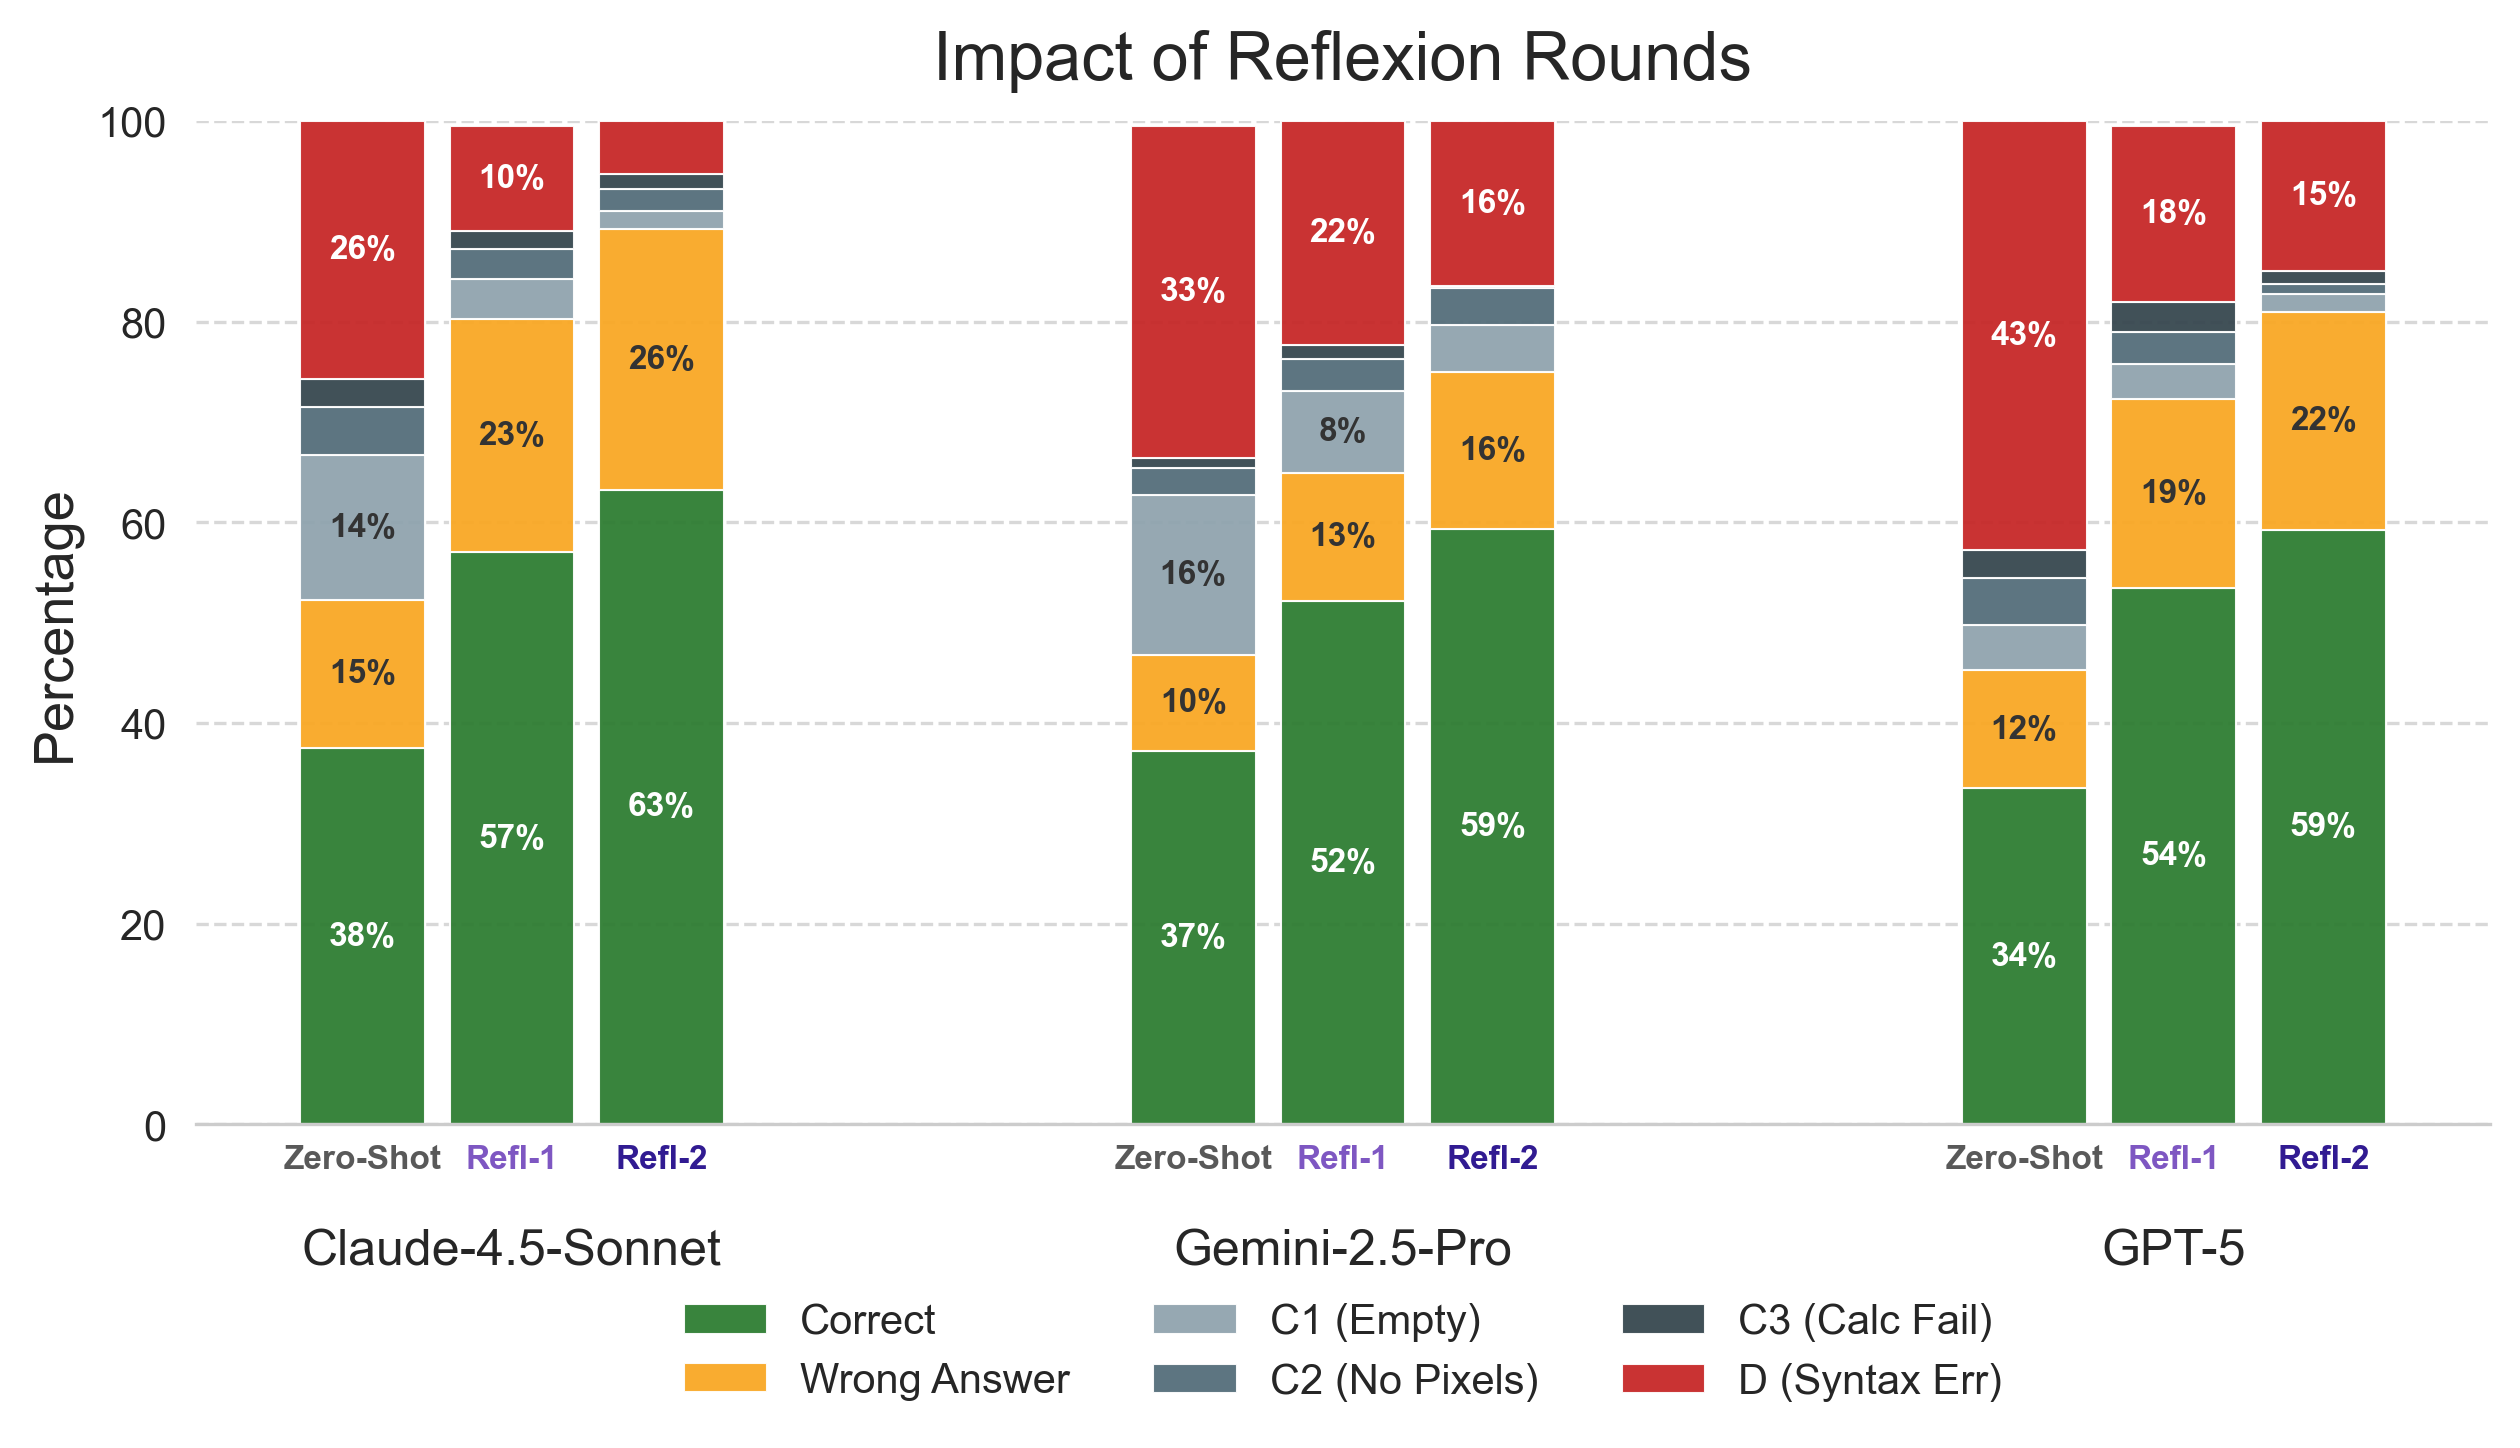

In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 1. CONFIGURATION & DATA PREP ---

# NOTE: Assumes 'df' is loaded with columns: 'code_llm', 'gt_answer', 'pred_code', 'stage'
# 'stage' values must include: 'zero_shot', 'reflexion1', 'reflexion2'

# Define Models and Order
target_models = ['claude-sonnet-4-5-20250929', 'gemini-2.5-pro', 'gpt-5']
model_labels = ['Claude-4.5-Sonnet', 'Gemini-2.5-Pro', 'GPT-5']

# Define Stages
stages = ['zero_shot', 'reflexion1', 'reflexion2']
stage_labels_map = {'zero_shot': 'Zero-Shot', 'reflexion1': 'Reflexion-1', 'reflexion2': 'Reflexion-2'}

# Filter Data
df_target = df[df['code_llm'].isin(target_models)].copy()
df_target['code_llm'] = pd.Categorical(df_target['code_llm'], categories=target_models, ordered=True)
df_target['stage'] = pd.Categorical(df_target['stage'], categories=stages, ordered=True)

# Define Outcomes
def categorize_result(row):
    gt = row['gt_answer']
    pred = row['pred_code']
    if (gt == 'Yes' and pred == 'A') or (gt == 'No' and pred == 'B'): return 'Correct'
    elif pred in ['A', 'B']: return 'Wrong Answer'
    elif pred == 'C1': return 'C1 (Empty)'
    elif pred == 'C2': return 'C2 (No Pixels)'
    elif pred == 'C3': return 'C3 (Calc Fail)'
    elif pred == 'D':  return 'D (Syntax Err)'
    return 'Unknown'

df_target['outcome'] = df_target.apply(categorize_result, axis=1)

# --- 2. COLOR PALETTES ---

# Text Colors for Stages
# Grey (Baseline) -> Medium Purple -> Deep Purple (Progressive improvement)
stage_colors = {
    'zero_shot':  '#595959', 
    'reflexion1': '#7E57C2', 
    'reflexion2': '#311B92'
} 

# Outcome Colors
stack_colors = {
    'Correct':      '#2E7D32', # Forest Green
    'Wrong Answer': '#F9A825', # Muted Orange/Yellow
    'C1 (Empty)':   '#90A4AE', # Blue Grey
    'C2 (No Pixels)':'#546E7A', # Darker Blue Grey
    'C3 (Calc Fail)':'#37474F', # Slate
    'D (Syntax Err)':'#C62828'  # Deep Red
}
outcome_order = ['Correct', 'Wrong Answer', 'C1 (Empty)', 'C2 (No Pixels)', 'C3 (Calc Fail)', 'D (Syntax Err)']

# --- 3. DATA CALCULATION ---

# Group by Model AND Stage
stack_data = df_target.groupby(['code_llm', 'stage', 'outcome']).size().unstack(fill_value=0)

# Calculate Percentages
stack_pct = stack_data.div(stack_data.sum(axis=1), axis=0) * 100

# Ensure all columns exist
for col in outcome_order:
    if col not in stack_pct.columns: 
        stack_pct[col] = 0
        
# Reorder columns
stack_pct = stack_pct[outcome_order]

# --- 4. PLOTTING ---

# Create single figure (Wider to fit 3 bars per model)
fig, ax = plt.subplots(figsize=(8.5, 5), dpi=300)
sns.set_style("whitegrid", {'axes.grid': False})

# Bar Layout Definitions
bar_width = 0.15  # Thinner bars to fit 3
gap = 0.03        # Small gap between bars
indices = np.arange(len(target_models))

# Calculate Positions for 3 bars centered on the index
# Logic: Center bar is at index. Left is index - (w+g). Right is index + (w+g).
pos_offsets = {
    'zero_shot':  -(bar_width + gap),
    'reflexion1': 0,
    'reflexion2': +(bar_width + gap)
}

# Helper function to plot a stack
def plot_stack(axis, positions, stage_key):
    try:
        subset = stack_pct.xs(stage_key, level='stage')
    except KeyError:
        return 
        
    bottoms = np.zeros(len(subset))
    
    for outcome in outcome_order:
        values = subset[outcome].values
        # Handle sparse data alignment
        if len(values) != len(positions): continue 

        axis.bar(
            positions, values, bottom=bottoms, width=bar_width, 
            label=outcome, 
            color=stack_colors[outcome], edgecolor='white', linewidth=0.5, alpha=0.95
        )
        
        # Add Percentage Labels
        for i, val in enumerate(values):
            if val > 6: 
                y_center = bottoms[i] + (val / 2)
                text_color = 'white' if outcome in ['Correct', 'D (Syntax Err)', 'C2 (No Pixels)', 'C3 (Calc Fail)'] else '#333333'
                axis.text(positions[i], y_center, f"{val:.0f}%", ha='center', va='center', 
                        color=text_color, fontsize=8, weight='bold') # Slightly smaller font
        
        bottoms += values

# Plot All 3 Stages
for stage in stages:
    current_pos = indices + pos_offsets[stage]
    plot_stack(ax, current_pos, stage)

# --- 5. STYLING & LABELS ---

ax.set_title('Impact of Reflexion Rounds', fontsize=16, pad=10)
ax.set_ylabel('Percentage', fontsize=13)
ax.set_xlabel('')

# X-Axis Settings
ax.set_xticks(indices)
ax.set_xticklabels(model_labels, fontsize=12, weight='medium')
ax.set_ylim(0, 100)
ax.grid(axis='y', linestyle='--', alpha=0.3, color='grey', zorder=0)

# Push the standard X-axis labels (Model Names) down 
ax.tick_params(axis='x', which='major', pad=25, length=0) 

# Add Custom Stage Labels under the bars
y_label_pos = -3.5

for i in indices:
    for stage in stages:
        # Calculate x position for this label
        x_pos = indices[i] + pos_offsets[stage]
        
        # Shorten text if needed for display
        label_text = stage_labels_map[stage]
        if label_text == "Reflexion-1": label_text = "Refl-1"
        if label_text == "Reflexion-2": label_text = "Refl-2"
        
        ax.text(x_pos, y_label_pos, label_text, ha='center', va='center', 
                fontsize=8, color=stage_colors[stage], weight='bold')

# Legend Logic
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles)) 

ax.legend(
    [by_label[k] for k in outcome_order], 
    outcome_order, 
    title='', 
    loc='upper center', 
    bbox_to_anchor=(0.5, -0.14), 
    ncol=3, 
    frameon=False,
    fontsize=10
)

sns.despine(left=True) 
plt.tight_layout()

# Save
plt.savefig('./figures/reflexion_rounds_comparison.pdf', dpi=300, bbox_inches='tight')
plt.show()